# Modeling Market Uncertainty Using Macroeconomic Indicators, Risk Metrics, and Monte Carlo Simulation

**Sample period:** January 2015 through December 2024  
**Assets and indicators:** S&P 500, VIX, CPI inflation, unemployment, and the Federal Funds Rate

### Abstract

This project investigates the relationship between financial market uncertainty and macroeconomic conditions using ten years of U.S. market data. Historical data for the S&P 500, the VIX, inflation, unemployment, and the Federal Funds Rate were collected and analyzed using Python. The analysis includes exploratory data analysis, multiple linear regression, Monte Carlo simulation, and financial risk metrics including the Sharpe Ratio, Value at Risk (VaR), and Expected Shortfall (CVaR). Finally, the project evaluates whether the VIX contains predictive information regarding future realized market volatility. The results demonstrate meaningful relationships between investor expectations and subsequent market behavior while illustrating practical applications of statistical and quantitative finance techniques.

# Motivation

One of the ideas that fascinated me while studying economics was the role of expectations in shaping future outcomes. In monetary economics, inflation expectations can influence actual inflation through the decisions of households, firms, and policymakers. This led me to wonder whether a similar idea exists in financial markets.

Unlike inflation expectations, the VIX does not directly cause future market volatility. Instead, it reflects investors' collective expectations of future market uncertainty. This raised an interesting question: **do these expectations contain useful information about the volatility that is ultimately realized?**

This project was motivated by that question. Using historical market and macroeconomic data, I investigate the relationship between investor expectations, macroeconomic conditions, and realized market volatility through statistical analysis, financial risk metrics, and Monte Carlo simulation.

# Introduction

Financial markets are characterized by uncertainty, making the measurement and prediction of risk an essential topic in economics and quantitative finance. Market volatility is influenced by macroeconomic conditions, investor sentiment, and expectations regarding future economic events. Understanding these relationships is valuable for investors, policymakers, and financial institutions seeking to manage risk and make informed decisions.

The objective of this project is to investigate the relationship between macroeconomic indicators and financial market uncertainty using historical data from the S&P 500, the VIX Volatility Index, inflation, unemployment, and the Federal Funds Rate. To accomplish this, the project applies statistical analysis, financial risk metrics, and Monte Carlo simulation to evaluate market behavior and quantify uncertainty.

Finally, the project examines whether the VIX, a forward-looking measure of expected market volatility, contains useful predictive information regarding future realized market volatility.

## Measurement and Interpretation Notes

- S&P 500 returns are simple daily percentage returns.
- Realized volatility is the annualized standard deviation of the previous 30 trading-day returns, expressed in percentage points.
- The VIX is also expressed in annualized percentage points, making the implied-versus-realized comparison dimensionally consistent.
- Correlations and regressions describe associations; they do not establish causation.
- The reported Sharpe-like ratio assumes a zero risk-free rate and is therefore a simplified risk-adjusted return measure.
- Monte Carlo results are conditional simulations based on historical parameters, not forecasts or confidence intervals.

# 1. Setup and Data Collection

This project combines historical financial-market data with U.S. macroeconomic indicators. S&P 500 and VIX data are obtained through Yahoo Finance, while inflation, unemployment, and Federal Funds Rate data are obtained from the Federal Reserve Economic Data (FRED) database.

The sample covers January 2015 through January 2025.

## 1.1 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf

from pandas_datareader import data as web

START_DATE = "2015-01-01"
END_DATE = "2025-01-01"

plt.rcParams["figure.figsize"] = (12, 6)

## 1.2 Download Financial-Market Data

The S&P 500 is used as a broad measure of U.S. equity-market performance. The VIX is used as a forward-looking measure of expected market volatility derived from options prices.

In [2]:
sp500 = yf.download(
    "^GSPC",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False,
)

vix = yf.download(
    "^VIX",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False,
)

print(f"S&P 500 observations: {len(sp500):,}")
print(f"VIX observations: {len(vix):,}")

S&P 500 observations: 2,516
VIX observations: 2,516


In [3]:
# Flatten yfinance MultiIndex columns for single-ticker downloads
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

if isinstance(vix.columns, pd.MultiIndex):
    vix.columns = vix.columns.get_level_values(0)

## 1.3 Download Macroeconomic Data

The macroeconomic variables used are the Consumer Price Index, the U.S. unemployment rate, and the Effective Federal Funds Rate.

In [4]:
inflation = web.DataReader("CPIAUCSL", "fred", START_DATE, END_DATE)
unemployment = web.DataReader("UNRATE", "fred", START_DATE, END_DATE)
interest_rate = web.DataReader("FEDFUNDS", "fred", START_DATE, END_DATE)

print(f"CPI observations: {len(inflation):,}")
print(f"Unemployment observations: {len(unemployment):,}")
print(f"Federal funds rate observations: {len(interest_rate):,}")

CPI observations: 121
Unemployment observations: 121
Federal funds rate observations: 121


# 2. Data Preparation

The raw data are transformed into variables suitable for statistical analysis. This includes calculating daily S&P 500 returns, merging the market datasets, estimating rolling realized volatility, calculating year-over-year inflation, and aligning daily financial data with monthly macroeconomic data.

## 2.1 Calculate Daily S&P 500 Returns

Daily returns measure the percentage change in the closing index level relative to the previous trading day.

In [5]:
sp500["Return"] = sp500["Close"].pct_change()

sp500[["Close", "Return"]].head()

Price,Close,Return
Date,,
2015-01-02,2058.199951,NaN
2015-01-05,2020.579956,-0.018278
2015-01-06,2002.609985,-0.008893
2015-01-07,2025.900024,0.011630
2015-01-08,2062.139893,0.017888


## 2.2 Combine S&P 500 Returns and VIX Data

In [6]:
combined = pd.DataFrame(
    {
        "SP500_Return": sp500["Return"],
        "VIX": vix["Close"],
    }
).dropna()

combined.head()

,SP500_Return,VIX
Date,,
2015-01-05,-0.018278,19.920000
2015-01-06,-0.008893,21.120001
2015-01-07,0.011630,19.309999
2015-01-08,0.017888,17.010000
2015-01-09,-0.008404,17.549999


## 2.3 Calculate 30-Day Rolling Realized Volatility

The rolling standard deviation of daily returns is used as a measure of recently realized market volatility.

In [7]:
combined["Realized_Volatility_30D"] = (
    combined["SP500_Return"]
    .rolling(window=30)
    .std()
    * np.sqrt(252)
    * 100
)

combined[
    ["SP500_Return", "Realized_Volatility_30D", "VIX"]
].tail()

,SP500_Return,Realized_Volatility_30D,VIX
Date,,,
2024-12-24,0.011043,12.384828,14.27
2024-12-26,-0.000406,12.351025,14.73
2024-12-27,-0.011056,12.784230,15.95
2024-12-30,-0.010702,13.042469,17.40
2024-12-31,-0.004285,12.515555,17.35


## 2.4 Calculate Year-over-Year Inflation

The CPI is a price-level index. The year-over-year percentage change in CPI is calculated to obtain an inflation-rate measure.

In [8]:
inflation["Inflation_Rate"] = (
    inflation["CPIAUCSL"].pct_change(periods=12) * 100
)

inflation[["CPIAUCSL", "Inflation_Rate"]].tail()

,CPIAUCSL,Inflation_Rate
DATE,,
2024-09-01,314.732,2.426483
2024-10-01,315.631,2.578844
2024-11-01,316.528,2.719472
2024-12-01,317.604,2.870691
2025-01-01,318.961,2.990978


## 2.5 Construct the Monthly Macro-Financial Dataset

Daily realized volatility is converted to a monthly frequency and aligned with inflation, unemployment, and interest-rate data. Dates are converted to monthly periods so observations from different sources match correctly.

# 3. Exploratory Data Analysis

Exploratory Data Analysis provides an initial view of market performance, investor uncertainty, and realized volatility before formal statistical modeling.

## 3.1 Historical Performance of the S&P 500

The S&P 500 shows the evolution of the broad U.S. equity market over the sample period.

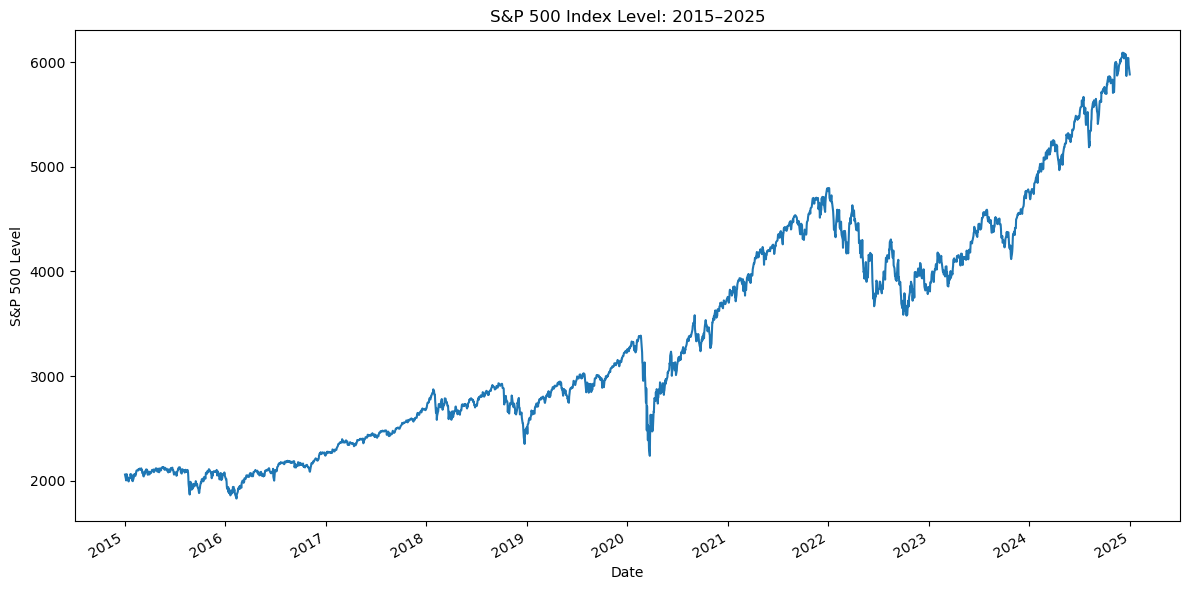

In [9]:
sp500["Close"].plot(figsize=(12,6), title="S&P 500 Index Level: 2015–2025")

plt.xlabel("Date")
plt.ylabel("S&P 500 Level")

plt.tight_layout()
plt.show()

### Interpretation

The S&P 500 displays a long-run upward trend between 2015 and 2025, interrupted by periods of market stress. The most visible decline occurs during the onset of the COVID-19 pandemic in early 2020. The subsequent recovery illustrates the difference between long-run market growth and short-run financial instability.

## 3.2 The VIX and Expected Market Volatility

The VIX reflects the options market's expectation of S&P 500 volatility over approximately the following 30 days. Higher values generally indicate greater perceived market uncertainty.

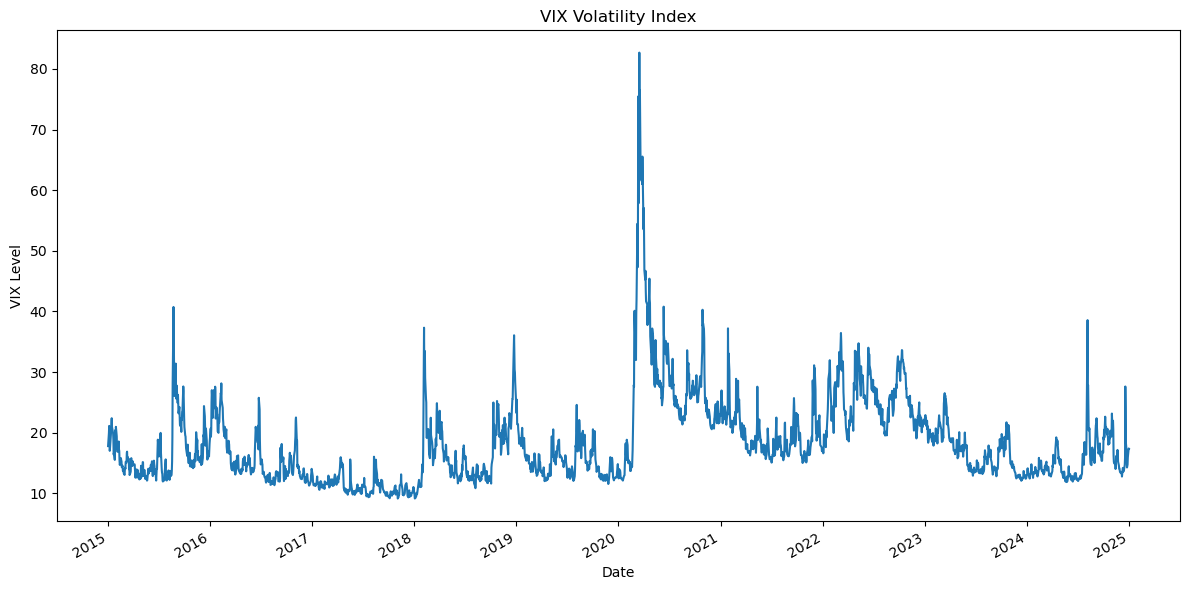

In [10]:
vix["Close"].plot(figsize=(12, 6), title="VIX Volatility Index")

plt.xlabel("Date")
plt.ylabel("VIX Level")
plt.tight_layout()
plt.show()

### Interpretation

The VIX remains relatively low during calm market conditions and rises sharply during periods of stress. Its largest spike in the sample occurs during the COVID-19 market shock, when uncertainty about economic activity and asset prices increased dramatically.

## 3.3 Relationship Between Daily Returns and the VIX

The correlation and scatter plot below examine whether higher expected volatility is associated with weaker daily S&P 500 performance.

In [11]:
correlation = combined["SP500_Return"].corr(combined["VIX"])

print(f"Correlation between S&P 500 returns and VIX: {correlation:.3f}")

Correlation between S&P 500 returns and VIX: -0.157


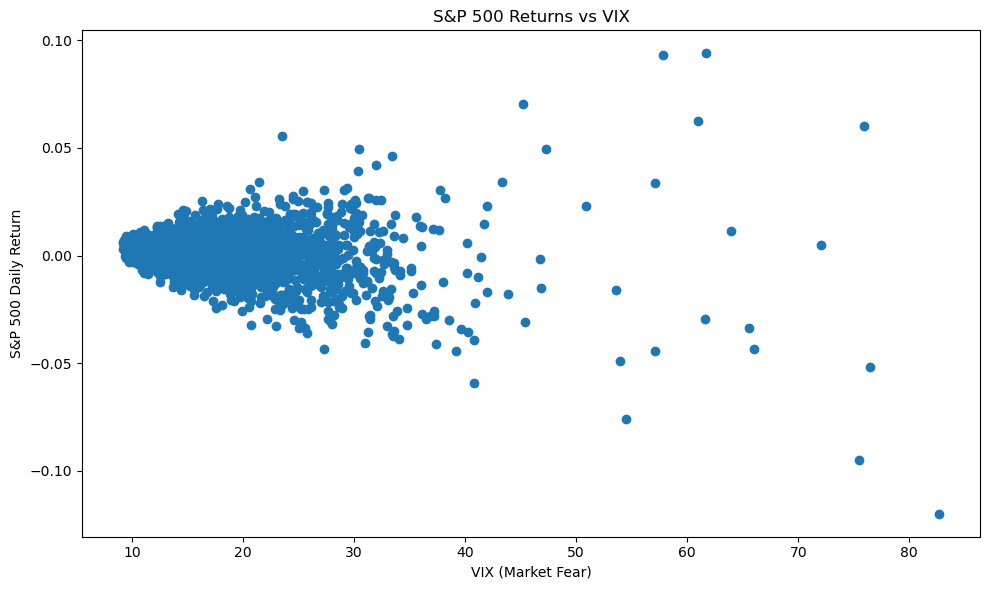

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(combined["VIX"], combined["SP500_Return"])

plt.title("S&P 500 Returns vs VIX")
plt.xlabel("VIX (Market Fear)")
plt.ylabel("S&P 500 Daily Return")

plt.tight_layout()
plt.show()

### Interpretation

The correlation is approximately **-0.157**, indicating a weak negative contemporaneous linear relationship between the VIX level and same-day S&P 500 returns. Higher VIX values tend to coincide with weaker returns, but daily market movements remain noisy and are influenced by many factors. The scatter plot also shows that high-VIX periods are associated with a wider dispersion of both positive and negative returns.

## 3.4 Thirty-Day Realized Volatility

Rolling volatility measures the variability of S&P 500 returns over the preceding 30 trading days.

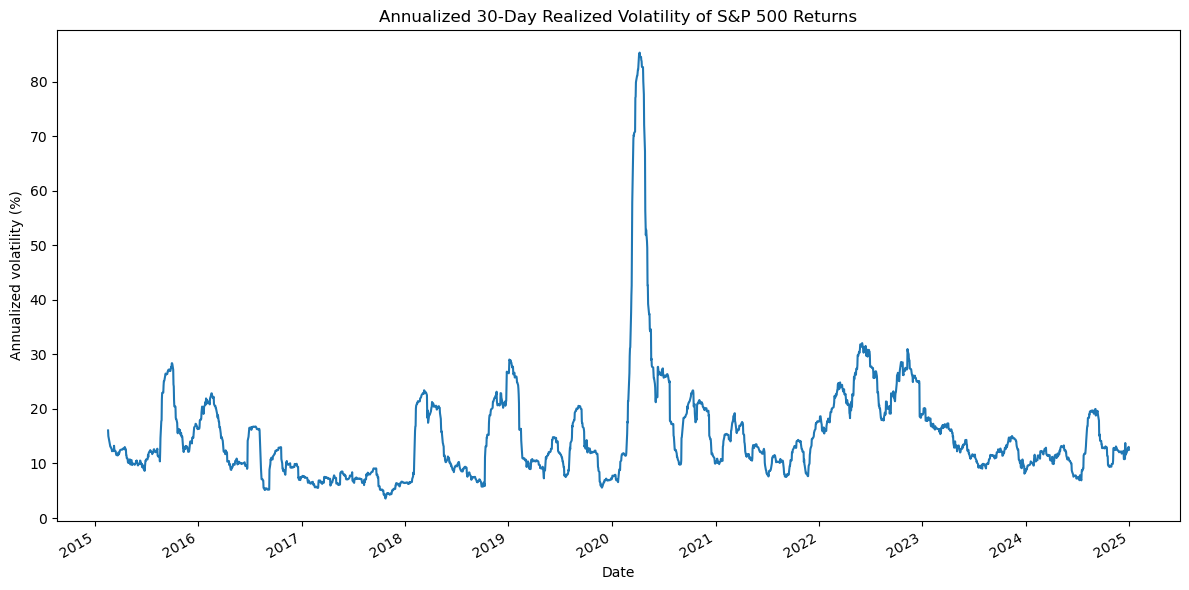

In [13]:
combined["Realized_Volatility_30D"].plot(
    figsize=(12, 6),
    title="Annualized 30-Day Realized Volatility of S&P 500 Returns",
)

plt.xlabel("Date")
plt.ylabel("Annualized volatility (%)")
plt.tight_layout()
plt.show()

### Interpretation

Realized volatility varies considerably through time and rises sharply during periods of market stress. The largest increase occurs in 2020, consistent with the unusually large daily price movements observed during the COVID-19 market shock.

## 3.5 Comparing Implied and Realized Volatility

The VIX represents implied, forward-looking volatility, whereas rolling volatility measures recently realized market fluctuations. The two series are scaled for visual comparison.

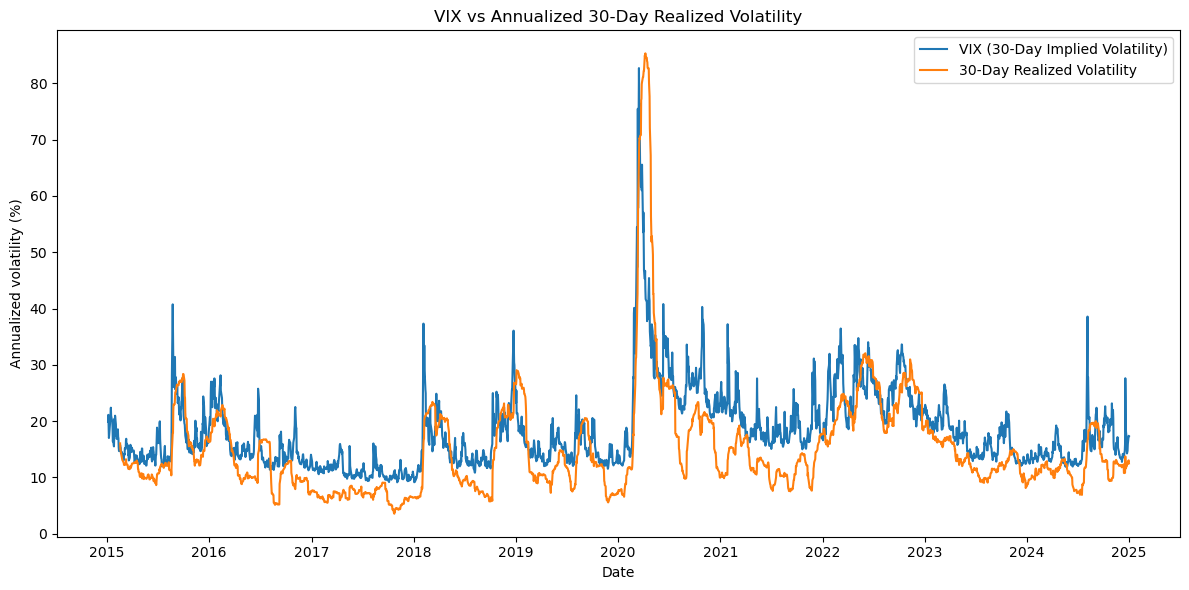

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(
    combined.index,
    combined["VIX"],
    label="VIX (30-Day Implied Volatility)",
)
plt.plot(
    combined.index,
    combined["Realized_Volatility_30D"],
    label="30-Day Realized Volatility",
)

plt.title("VIX vs Annualized 30-Day Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized volatility (%)")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

Implied and realized volatility, now measured on the same annualized percentage scale, display similar broad movements, particularly during major periods of market stress. This suggests that investors' expectations and subsequently observed market instability are closely related, although the comparison alone does not establish causation or predictive accuracy.

# 4. Macroeconomic Analysis

This section examines inflation, monetary policy, unemployment, and their relationships with market volatility.

## 4.1 Consumer Price Index

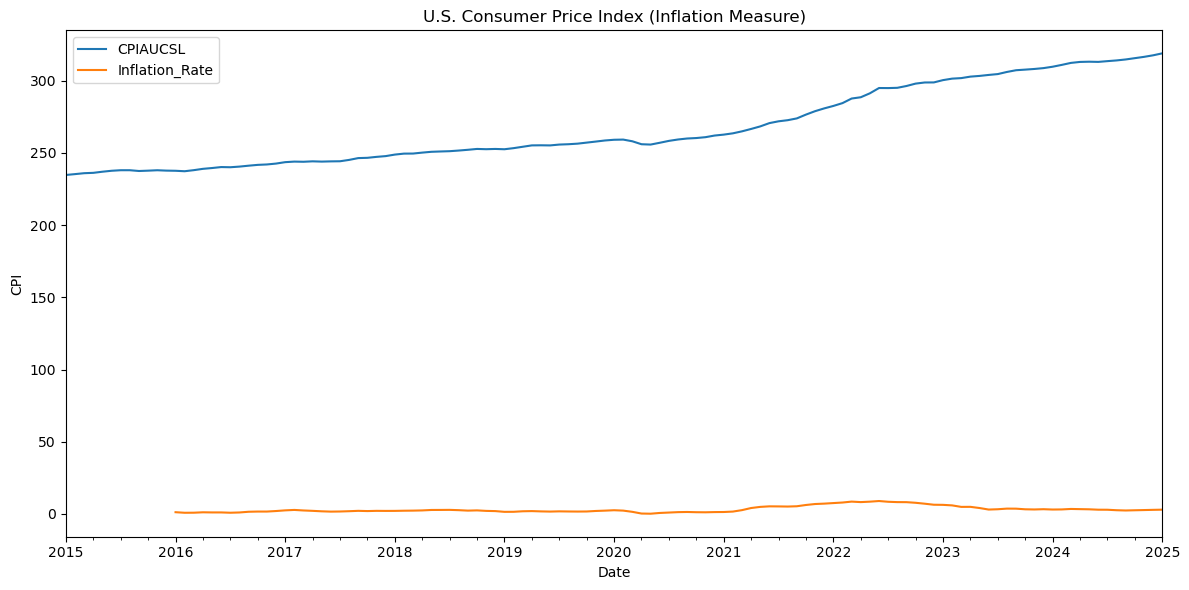

In [15]:
inflation.plot(figsize=(12,6), title="U.S. Consumer Price Index (Inflation Measure)")

plt.xlabel("Date")
plt.ylabel("CPI")

plt.tight_layout()
plt.show()

The CPI level rises over time, with a visibly faster increase following the pandemic. Because CPI is a price-level measure rather than an inflation rate, its slope indicates how rapidly prices are changing.

## 4.2 Year-over-Year Inflation

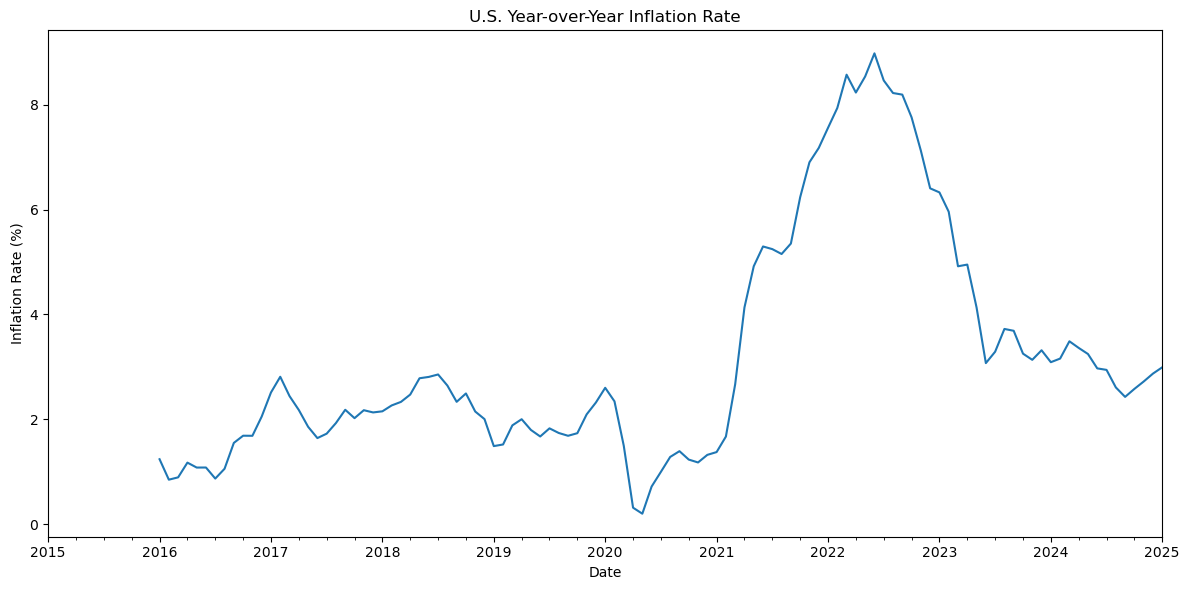

In [16]:
inflation["Inflation_Rate"].plot(
    figsize=(12,6),
    title="U.S. Year-over-Year Inflation Rate"
)

plt.xlabel("Date")
plt.ylabel("Inflation Rate (%)")

plt.tight_layout()
plt.show()

Year-over-year inflation declines briefly during the initial pandemic shock and subsequently rises sharply during 2021–2022. It later moderates as supply conditions normalize and monetary policy becomes more restrictive.

## 4.3 Federal Funds Rate

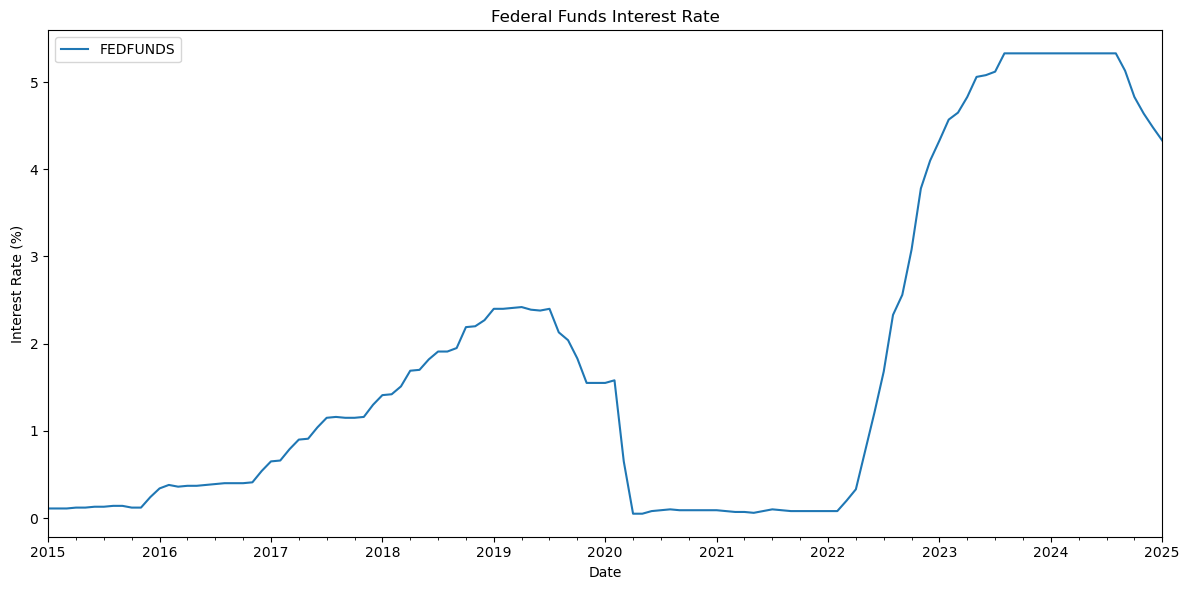

In [17]:
interest_rate.plot(
    figsize=(12,6),
    title="Federal Funds Interest Rate"
)

plt.xlabel("Date")
plt.ylabel("Interest Rate (%)")

plt.tight_layout()
plt.show()

The Federal Funds Rate was reduced to near zero during the pandemic and then increased rapidly beginning in 2022 as the Federal Reserve responded to elevated inflation.

## 4.4 Unemployment Rate

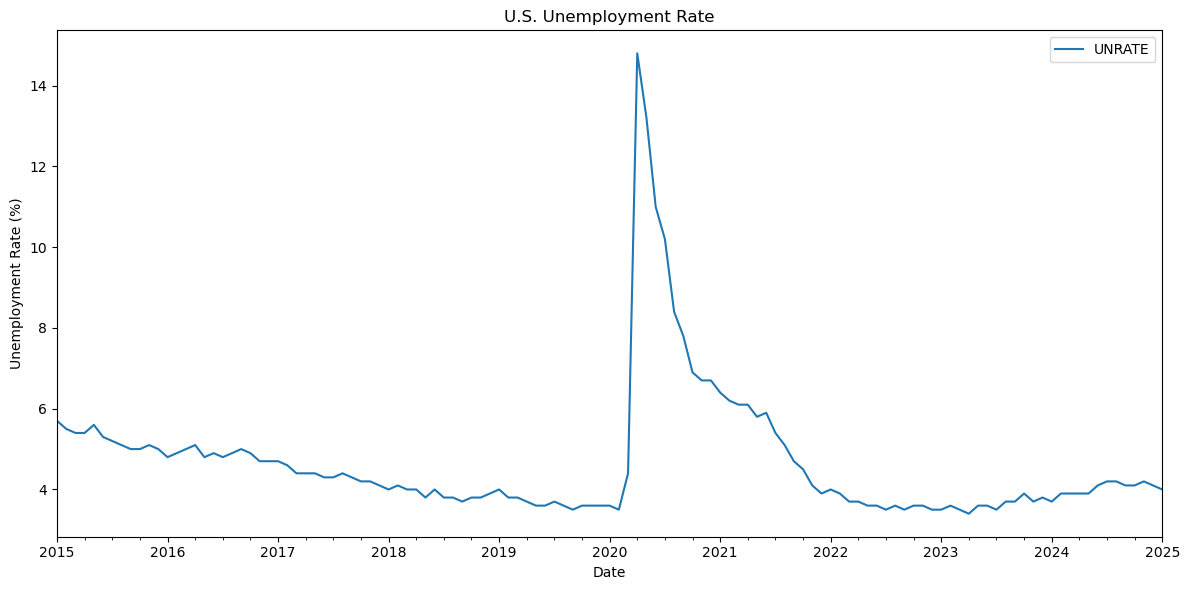

In [18]:
unemployment.plot(
    figsize=(12,6),
    title="U.S. Unemployment Rate"
)

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.tight_layout()
plt.show()

The unemployment rate declines through the pre-pandemic expansion, spikes dramatically in 2020, and then falls as economic activity and employment recover.

## 4.5 Macro-Financial Correlation Matrix

The correlation matrix provides an initial measure of the linear relationships among inflation, unemployment, interest rates, and monthly market volatility.

In [19]:
macro = pd.DataFrame({
    "Inflation_Rate": inflation["Inflation_Rate"],
    "Unemployment": unemployment["UNRATE"],
    "Interest_Rate": interest_rate["FEDFUNDS"],
})

monthly_volatility = (
    combined["Realized_Volatility_30D"]
    .resample("ME")
    .mean()
)

macro.index = macro.index.to_period("M")
monthly_volatility.index = monthly_volatility.index.to_period("M")

macro["Market_Volatility"] = monthly_volatility

macro = macro.dropna()

macro.head()

,Inflation_Rate,Unemployment,Interest_Rate,Market_Volatility
DATE,,,,
2016-01,1.237503,4.8,0.34,19.233632
2016-02,0.847278,4.9,0.38,21.656504
2016-03,0.891616,5.0,0.36,16.982858
2016-04,1.172626,5.1,0.37,10.624491
2016-05,1.078476,4.8,0.37,10.109183


In [20]:
# Basic reproducibility and data-quality checks
assert not sp500.empty and not vix.empty
assert sp500.index.is_monotonic_increasing
assert vix.index.is_monotonic_increasing
assert combined.index.is_unique
assert macro.index.is_unique
assert combined[["SP500_Return", "VIX"]].notna().all().all()
assert macro.notna().all().all()

print("All data-quality checks passed.")

All data-quality checks passed.


In [21]:
macro.corr().round(3)

,Inflation_Rate,Unemployment,Interest_Rate,Market_Volatility
Inflation_Rate,1.000,-0.367,0.117,0.110
Unemployment,-0.367,1.000,-0.436,0.490
Interest_Rate,0.117,-0.436,1.000,-0.132
Market_Volatility,0.110,0.490,-0.132,1.000


### Interpretation

Among the macroeconomic variables examined, unemployment has the strongest positive correlation with market volatility. This is consistent with major economic stress episodes producing both labor-market deterioration and greater financial uncertainty. These correlations are descriptive and should not be interpreted as causal effects.

## 4.6 Multiple Regression Analysis

An Ordinary Least Squares regression is estimated with monthly market volatility as the dependent variable and inflation, unemployment, and the Federal Funds Rate as explanatory variables.

In [22]:
X_macro = macro[
    ["Inflation_Rate", "Unemployment", "Interest_Rate"]
]
y_macro = macro["Market_Volatility"]

X_macro = sm.add_constant(X_macro)
macro_model = sm.OLS(y_macro, X_macro).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 3},
)

print(macro_model.summary())

                            OLS Regression Results                            
Dep. Variable:      Market_Volatility   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     7.300
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           0.000172
Time:                        18:27:37   Log-Likelihood:                -374.30
No. Observations:                 108   AIC:                             756.6
Df Residuals:                     104   BIC:                             767.3
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -7.1681      4.632     -1.

### Interpretation

The model explains approximately **34.8%** of the observed variation in monthly market volatility. Unemployment displays the strongest positive association with volatility in this specification. Inflation also has a positive estimated coefficient, while the interest-rate coefficient is not statistically significant at conventional levels. These estimates describe conditional associations rather than causal effects.

# 5. Financial Risk Analysis

This section evaluates historical S&P 500 risk from three perspectives: risk-adjusted performance, the threshold for unusually poor daily outcomes, and the severity of losses within the extreme left tail.

## 5.1 Sharpe Ratio

The Sharpe Ratio compares average return with return volatility. The calculation below uses daily S&P 500 returns and annualizes the ratio using 252 trading days. Because no risk-free rate is subtracted, the result should be interpreted as a simplified historical risk-adjusted return measure.

In [23]:
daily_return = sp500["Return"].mean()
daily_volatility = sp500["Return"].std()

sharpe_ratio = (daily_return / daily_volatility) * np.sqrt(252)

print(f"Annualized Sharpe ratio: {sharpe_ratio:.3f}")

Annualized Sharpe ratio: 0.680


### Interpretation

The estimated zero-risk-free-rate Sharpe-like ratio is approximately **0.680**, indicating moderate historical return relative to volatility over the sample period. Investors were compensated for bearing risk, although major stress periods reduced overall risk-adjusted performance.

## 5.2 Value at Risk

Historical 95% daily Value at Risk identifies the return threshold exceeded by the worst 5% of observed trading days.

In [24]:
var_95 = np.percentile(sp500["Return"].dropna(), 5)

print(f"95% daily Value at Risk: {var_95:.2%}")

95% daily Value at Risk: -1.69%


Interpretation: The historical 5th percentile of daily S&P 500 returns is approximately **-1.69%**. In the sample, about 95% of daily returns were above this threshold and about 5% were below it. This is an empirical historical estimate and does not guarantee future losses will remain within the threshold.

## 5.3 Expected Shortfall

Expected Shortfall measures the average loss conditional on being within the worst 5% of trading days.

In [25]:
expected_shortfall_95 = sp500.loc[
    sp500["Return"] <= var_95,
    "Return",
].mean()

print(f"95% daily Expected Shortfall: {expected_shortfall_95:.2%}")

95% daily Expected Shortfall: -2.74%


Interpretation: Among observations below the historical 95% VaR threshold, the average daily return was approximately **-2.74%**. Expected Shortfall therefore summarizes the average severity of the sample's worst 5% of daily outcomes rather than only identifying the cutoff.

# 6. Monte Carlo Simulation

Monte Carlo methods generate many possible one-year S&P 500 paths using the historical average daily return and volatility. The simulation illustrates uncertainty under a simplified model rather than providing a precise market forecast.

## 6.1 Estimate Simulation Parameters

In [26]:
mu = sp500["Return"].mean()
sigma = sp500["Return"].std()

print(f"Average daily return: {mu:.6f}")
print(f"Daily volatility: {sigma:.6f}")

Average daily return: 0.000481
Daily volatility: 0.011230


## 6.2 Simulated One-Year Price Paths

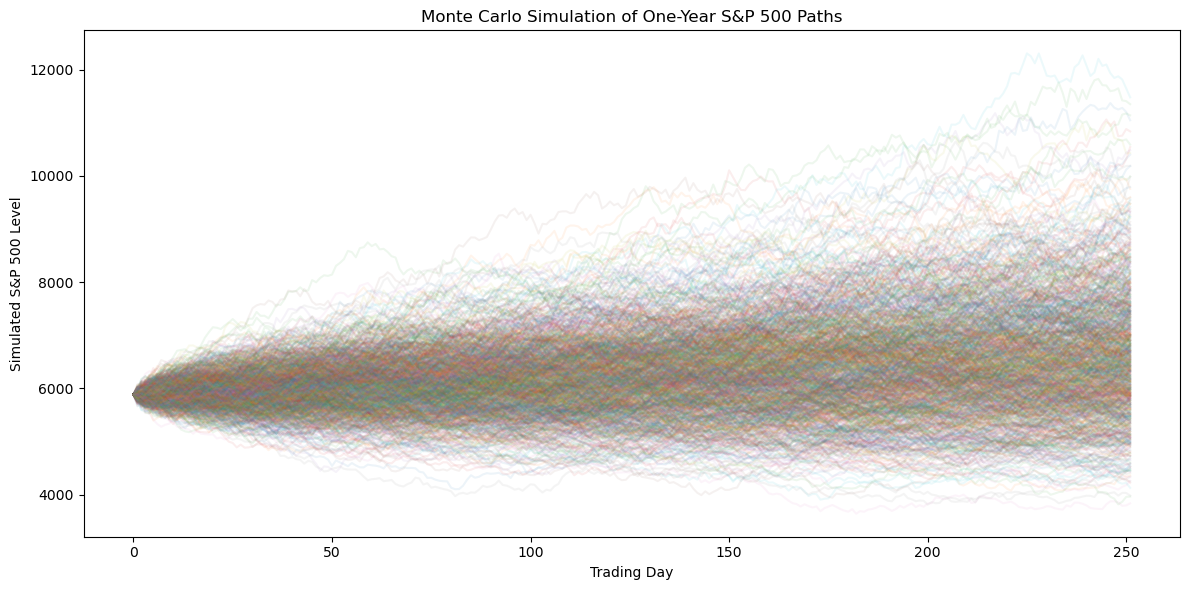

In [27]:
initial_price = float(sp500["Close"].iloc[-1])
trading_days = 252
n_simulations = 1_000
rng = np.random.default_rng(42)

simulated_paths = np.zeros((trading_days, n_simulations))
simulated_paths[0] = initial_price

for simulation in range(n_simulations):
    for day in range(1, trading_days):
        random_shock = rng.normal()
        simulated_paths[day, simulation] = (
            simulated_paths[day - 1, simulation]
            * (1 + mu + sigma * random_shock)
        )

plt.figure(figsize=(12, 6))
plt.plot(simulated_paths, alpha=0.08)
plt.title("Monte Carlo Simulation of One-Year S&P 500 Paths")
plt.xlabel("Trading Day")
plt.ylabel("Simulated S&P 500 Level")
plt.tight_layout()
plt.show()

## 6.3 Distribution of Simulated Ending Values

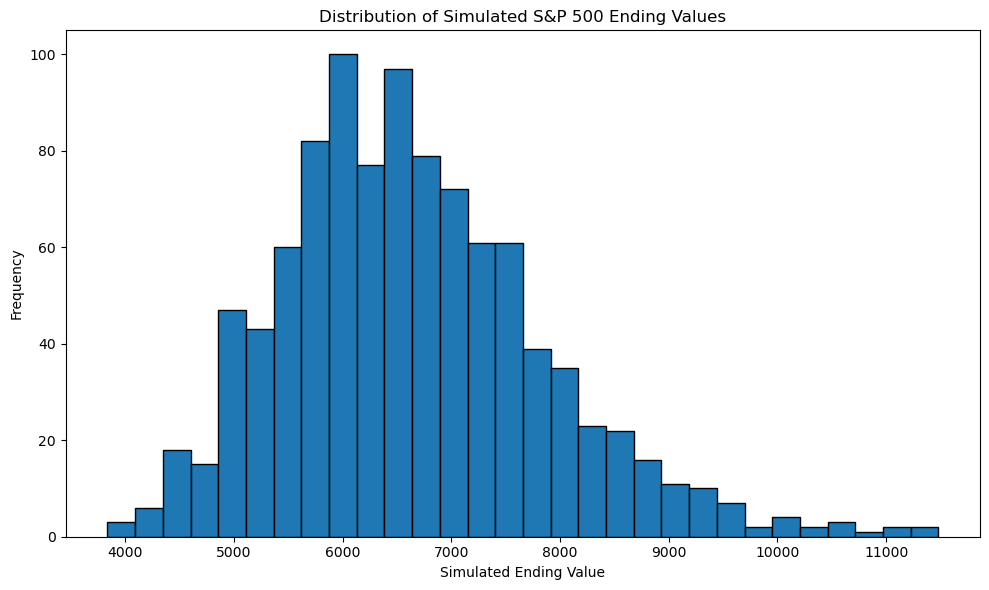

In [28]:
ending_prices = simulated_paths[-1]

plt.figure(figsize=(10, 6))
plt.hist(ending_prices, bins=30, edgecolor="black")
plt.title("Distribution of Simulated S&P 500 Ending Values")
plt.xlabel("Simulated Ending Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Interpretation: The histogram illustrates the distribution of simulated S&P 500 index levels after one trading year across 1,000 Monte Carlo simulations. Most simulations resulted in ending values between approximately 5,500 and 8,000, with fewer simulations producing extremely high or low outcomes. The distribution highlights the uncertainty inherent in financial markets and demonstrates that a wide range of future outcomes is plausible, even when using the same historical return and volatility estimates.

## 6.4 Summary Statistics

In [29]:
print(f"Mean ending value: {np.mean(ending_prices):,.2f}")
print(f"Median ending value: {np.median(ending_prices):,.2f}")
print(f"Minimum ending value: {np.min(ending_prices):,.2f}")
print(f"Maximum ending value: {np.max(ending_prices):,.2f}")
print(f"5th percentile: {np.percentile(ending_prices, 5):,.2f}")
print(f"95th percentile: {np.percentile(ending_prices, 95):,.2f}")

Mean ending value: 6,635.31
Median ending value: 6,503.85
Minimum ending value: 3,834.32
Maximum ending value: 11,481.12
5th percentile: 4,938.73
95th percentile: 8,804.83


Interpretation: With the fixed random seed used in this notebook, the 1,000 simulations produced a mean ending level of **6,635.31** and a median of **6,503.85**. Outcomes ranged from **3,834.32** to **11,481.12**, while the central 90% simulation interval extended from **4,938.73** to **8,804.83**. These figures are conditional on the model and historical parameter estimates; they are not forecasts.

## 6.5 Median Path and 90% Simulation Band

In [30]:
lower_band = np.percentile(simulated_paths, 5, axis=1)
median_path = np.percentile(simulated_paths, 50, axis=1)
upper_band = np.percentile(simulated_paths, 95, axis=1)

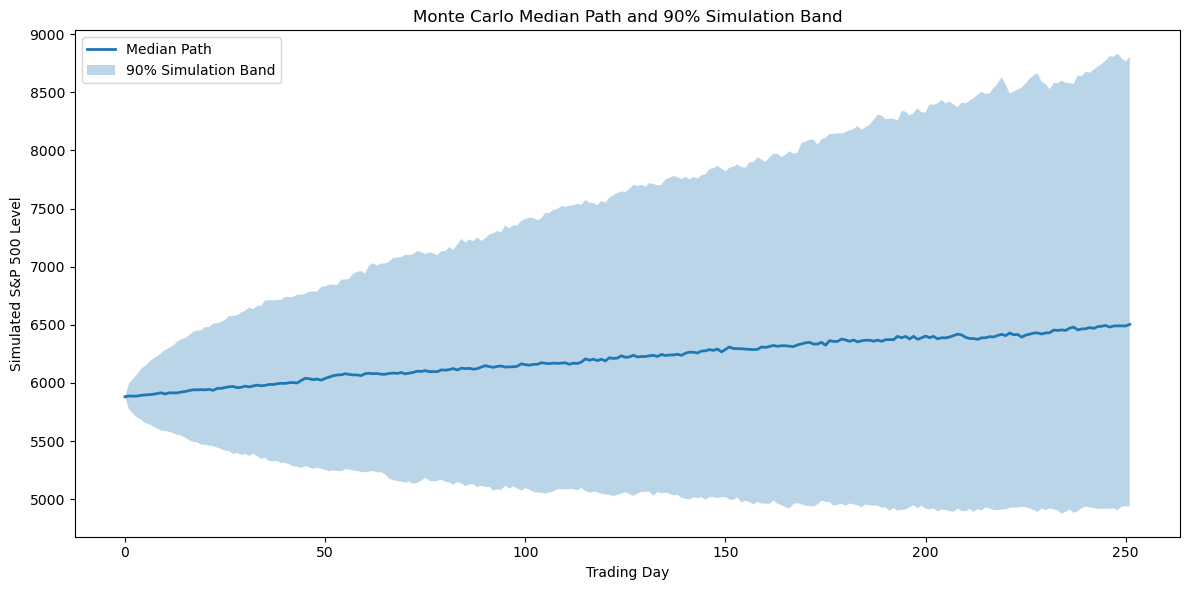

In [31]:
simulation_days = np.arange(trading_days)

plt.figure(figsize=(12, 6))
plt.plot(
    simulation_days,
    median_path,
    linewidth=2,
    label="Median Path",
)
plt.fill_between(
    simulation_days,
    lower_band,
    upper_band,
    alpha=0.3,
    label="90% Simulation Band",
)
plt.title("Monte Carlo Median Path and 90% Simulation Band")
plt.xlabel("Trading Day")
plt.ylabel("Simulated S&P 500 Level")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation: The Monte Carlo simulation summarizes 1,000 possible one-year paths for the S&P 500 based on its historical average daily return and volatility. The median simulated path (blue line) shows a gradual increase in the index over time, reflecting the positive historical average return. The shaded region represents the central 90% simulation band, bounded by the 5th and 95th percentiles of all simulated paths. As the simulation progresses, the confidence band widens considerably, illustrating that uncertainty accumulates over time and a broader range of future market outcomes becomes possible.

## 6.6 Model Limitations

This simulation assumes independent daily shocks and constant historical mean and volatility. Real financial markets exhibit changing volatility, non-normal tail behavior, structural breaks, and evolving economic conditions. The simulation is therefore an illustrative scenario model rather than a reliable forecast.

# 7. Predictive Analysis: Can the VIX Predict Future Realized Volatility?

## 7.1 Research Question and Hypothesis

The VIX reflects expected volatility over approximately the next 30 days. The central hypothesis is that higher VIX values will be associated with higher realized S&P 500 volatility over the following 30 trading days.

## 7.1 Construct Future Realized Volatility

The 30-day rolling realized-volatility series is shifted backward by 30 observations so that each current VIX observation is paired with volatility measured approximately one trading month later.

In [32]:
predictive_data = combined.copy()

# At each date t, use returns from t+1 through t+30.
predictive_data["Future_Realized_Vol"] = (
    predictive_data["SP500_Return"]
    .shift(-1)
    .rolling(window=30)
    .std()
    .shift(-29)
    * np.sqrt(252)
    * 100
)

predictive_data = predictive_data.dropna()

predictive_data[["VIX", "Future_Realized_Vol"]].head()

,VIX,Future_Realized_Vol
Date,,
2015-02-17,15.80,12.405946
2015-02-18,15.45,12.446533
2015-02-19,15.29,12.503092
2015-02-20,14.30,12.525923
2015-02-23,14.56,12.534599


## 7.2 Correlation Analysis

In [33]:
predictive_data = combined.copy()

# At each date t, use returns from t+1 through t+30.
predictive_data["Future_Realized_Vol"] = (
    predictive_data["SP500_Return"]
    .shift(-1)
    .rolling(window=30)
    .std()
    .shift(-29)
    * np.sqrt(252)
    * 100
)

predictive_data = predictive_data.dropna()

predictive_data[["VIX", "Future_Realized_Vol"]].head()

,VIX,Future_Realized_Vol
Date,,
2015-02-17,15.80,12.405946
2015-02-18,15.45,12.446533
2015-02-19,15.29,12.503092
2015-02-20,14.30,12.525923
2015-02-23,14.56,12.534599


Interpretation: The correlation between today's VIX and future 30-day realized volatility is approximately 0.55, indicating a moderate positive relationship. This suggests that periods of elevated implied volatility are generally followed by periods of higher realized market volatility. While the relationship is not perfect, the VIX appears to contain meaningful information regarding future market uncertainty.

## 7.3 Scatter Plot

In [34]:
predictive_data = combined.copy()

# At each date t, use returns from t+1 through t+30.
predictive_data["Future_Realized_Vol"] = (
    predictive_data["SP500_Return"]
    .shift(-1)
    .rolling(window=30)
    .std()
    .shift(-29)
    * np.sqrt(252)
    * 100
)

predictive_data = predictive_data.dropna()

predictive_data[["VIX", "Future_Realized_Vol"]].head()

,VIX,Future_Realized_Vol
Date,,
2015-02-17,15.80,12.405946
2015-02-18,15.45,12.446533
2015-02-19,15.29,12.503092
2015-02-20,14.30,12.525923
2015-02-23,14.56,12.534599


### Interpretation

The scatter plot shows an upward relationship: higher current VIX levels are generally associated with higher subsequent realized volatility. The relationship is meaningful but imperfect, reflecting the uncertainty and noise inherent in financial markets.

## 7.4 Predictive Regression

A simple OLS model is estimated with future realized volatility as the dependent variable and the current VIX as the explanatory variable.

In [35]:
predictive_data = combined.copy()

# At each date t, use returns from t+1 through t+30.
predictive_data["Future_Realized_Vol"] = (
    predictive_data["SP500_Return"]
    .shift(-1)
    .rolling(window=30)
    .std()
    .shift(-29)
    * np.sqrt(252)
    * 100
)

predictive_data = predictive_data.dropna()

predictive_data[["VIX", "Future_Realized_Vol"]].head()

,VIX,Future_Realized_Vol
Date,,
2015-02-17,15.80,12.405946
2015-02-18,15.45,12.446533
2015-02-19,15.29,12.503092
2015-02-20,14.30,12.525923
2015-02-23,14.56,12.534599


Interpretation: Using heteroskedasticity- and autocorrelation-consistent standard errors, the regression evaluates whether the VIX is a statistically significant predictor of future 30-day realized market volatility. The estimated coefficient is positive, suggesting that higher levels of implied volatility are associated with higher future realized volatility. Furthermore, the model explains approximately 30% of the variation in future realized volatility (R² = 0.300), indicating that while the VIX contains meaningful predictive information, a substantial portion of future volatility remains driven by other market factors.

## 7.5 Discussion

The results support the hypothesis that the VIX contains useful information about future realized volatility. A correlation of approximately **0.548** indicates a moderate positive relationship, while the regression explains approximately **30%** of the variation in future realized volatility. A positive VIX coefficient, when statistically significant under HAC inference, supports predictive association, although most future volatility remains driven by other factors. These results establish predictive association, not causation.

# 8. Conclusion

This project examined financial-market uncertainty using market data, macroeconomic indicators, risk measures, simulation, and predictive regression. The S&P 500 and VIX analyses highlighted the large increase in uncertainty surrounding the COVID-19 shock. Realized and implied volatility displayed similar broad patterns, while unemployment showed the strongest association with market volatility among the macroeconomic variables examined.

Historical risk analysis produced a simplified Sharpe Ratio of approximately **0.68**, a 95% daily VaR of approximately **-1.69%**, and a 95% Expected Shortfall of approximately **-2.74%**. The Monte Carlo analysis illustrated how the range of plausible market outcomes widens over time as uncertainty accumulates.

The predictive analysis provided the project's central result: the current VIX had a correlation of approximately **0.548** with future 30-day realized volatility, and the corresponding regression explained approximately **30%** of its variation. The VIX therefore appears to contain meaningful, though incomplete, information about subsequent market uncertainty.

Overall, the project demonstrates how Python can combine economics, financial data analysis, econometrics, risk management, and stochastic simulation within one reproducible research workflow.

# 9. Future Work

Possible extensions include:

- estimating GARCH-family volatility models;
- evaluating predictive performance on a genuinely separate out-of-sample period;
- comparing the VIX model against simple historical-volatility benchmarks;
- incorporating additional macroeconomic and financial predictors;
- testing alternative horizons such as 5, 10, 60, and 90 trading days;
- adding portfolio optimization and asset-allocation analysis;
- incorporating option-pricing and implied-volatility analysis;
- using expanding-window or rolling-window model estimation to avoid look-ahead bias.